<h3><center>TP IS</center></h3>


<h3><center>Echantillonnage et transformée de Fourier</center></h3>

Soit un signal $s1$ de longueur $3 ms$, échantillonné à $fe = 2000 kHz$. Ce signal est :

- pendant la première milliseconde, un signal cosinusoïdal de fréquence $300 kHz$ ;
- pendant la deuxième milliseconde, un signal cosinusoïdal de fréquence $500 kHz$ ;
- pendant la troisième milliseconde, un signal cosinusoïdal de fréquence $700 kHz$.

***

**1)- 3pts** Générer le signal $s1$ et afficher le en fonction du temps, en faisant clairement apparaître l’axe du temps.


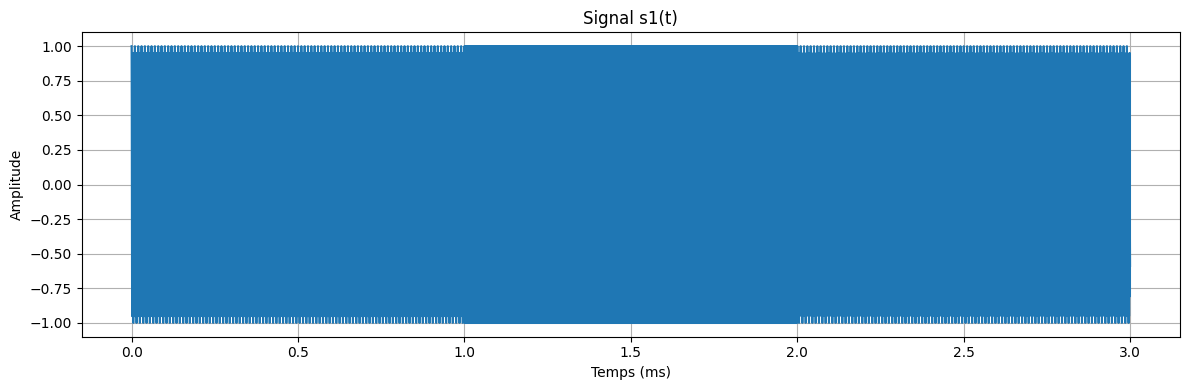

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fe = 2000e3
Te = 1 / fe
duree = 3e-3

t = np.arange(0, duree, Te)
N = len(t)

s1 = np.zeros(N)
n1 = int(1e-3 / Te)
n2 = int(2e-3 / Te)

s1[:n1] = np.cos(2 * np.pi * 300e3 * t[:n1])
s1[n1:n2] = np.cos(2 * np.pi * 500e3 * t[n1:n2])
s1[n2:] = np.cos(2 * np.pi * 700e3 * t[n2:])

plt.figure(figsize=(12, 4))
plt.plot(t * 1e3, s1)
plt.title('Signal s1(t)')
plt.xlabel('Temps (ms)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

**2)** Calculer la transformée de Fourier du signal $s1$ et afficher son module, en faisant clairement apparaître l’axe des fréquences :

> **a)- 3pts** un plot pour les fréquences en $Hz$ ;

> **b)- 3pts** un plot pour les fréquences normalisées.

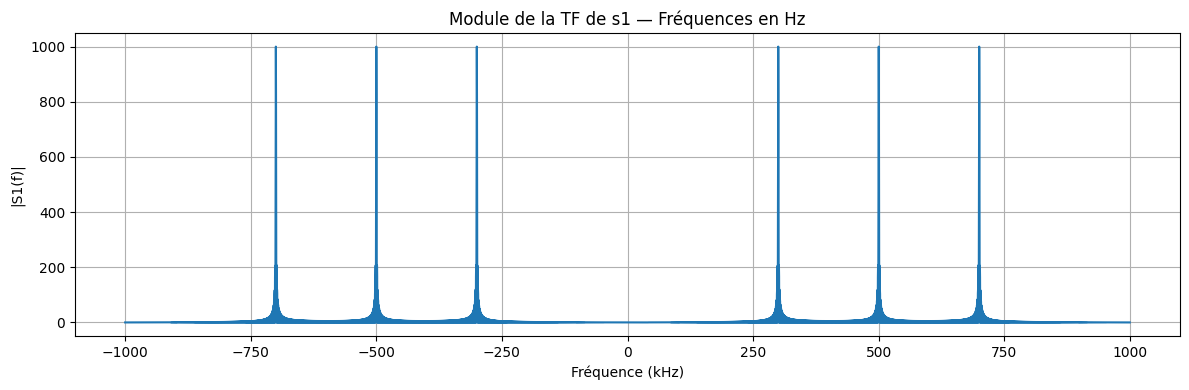

In [2]:
# 2a) TF - fréquences en Hz
S1 = np.fft.fft(s1)
freqs = np.fft.fftfreq(N, d=Te)

plt.figure(figsize=(12, 4))
plt.plot(np.fft.fftshift(freqs) / 1e3, np.abs(np.fft.fftshift(S1)))
plt.title('Module de la TF de s1 — Fréquences en Hz')
plt.xlabel('Fréquence (kHz)')
plt.ylabel('|S1(f)|')
plt.grid(True)
plt.tight_layout()
plt.show()

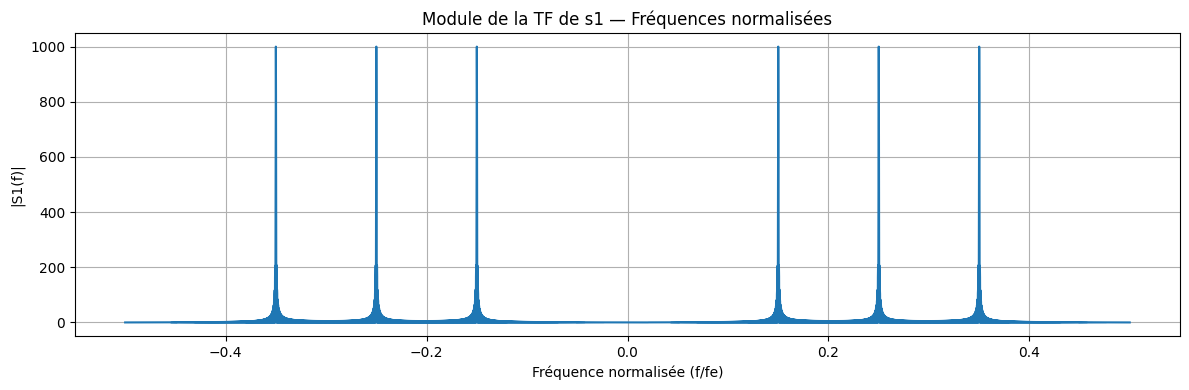

In [3]:
# 2b) TF - fréquences normalisées
f_norm = np.fft.fftshift(np.fft.fftfreq(N))

plt.figure(figsize=(12, 4))
plt.plot(f_norm, np.abs(np.fft.fftshift(S1)))
plt.title('Module de la TF de s1 — Fréquences normalisées')
plt.xlabel('Fréquence normalisée (f/fe)')
plt.ylabel('|S1(f)|')
plt.grid(True)
plt.tight_layout()
plt.show()

**3)- 3pts** Commenter l’allure du spectre obtenu en 2). Est-ce que ce signal a été correctement échantillonné ? Justifier votre réponse.

*Commentaires*: 

Le spectre montre 3 paires de pics symétriques à $\pm 300$ kHz, $\pm 500$ kHz et $\pm 700$ kHz, correspondant aux 3 composantes cosinusoïdales du signal. Le signal est **correctement échantillonné** car $f_e = 2000$ kHz $> 2 \times f_{max} = 2 \times 700 = 1400$ kHz (théorème de Shannon respecté). Il n'y a pas de repliement spectral (aliasing).

**4) - BONUS 1pts** Proposer et mettre en œuvre un filtre pour garder les fréquences entre $250 kHz$ et $350 kHz$ (et les
fréquences négatives correspondantes) et éliminer toutes les autres fréquences.

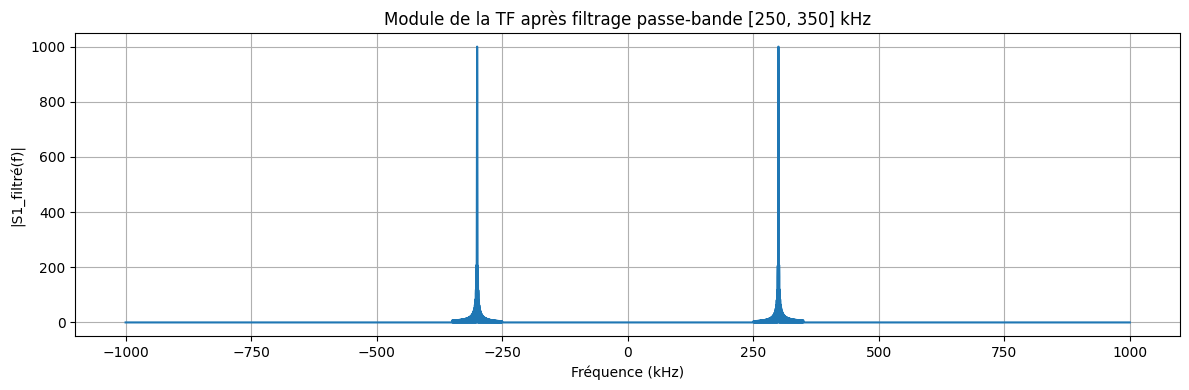

In [4]:
# Q4 - Filtre passe-bande [250 kHz, 350 kHz]
S1 = np.fft.fft(s1)
freqs = np.fft.fftfreq(N, d=Te)

H_bp = ((np.abs(freqs) >= 250e3) & (np.abs(freqs) <= 350e3)).astype(float)

S1_filtre = S1 * H_bp

plt.figure(figsize=(12, 4))
plt.plot(np.fft.fftshift(freqs) / 1e3, np.abs(np.fft.fftshift(S1_filtre)))
plt.title('Module de la TF après filtrage passe-bande [250, 350] kHz')
plt.xlabel('Fréquence (kHz)')
plt.ylabel('|S1_filtré(f)|')
plt.grid(True)
plt.tight_layout()
plt.show()

**5) - BONUS - 3pts** Afficher alors le signal filtré obtenu, en faisant clairement apparaître l’axe du temps. Commenter le résultat.

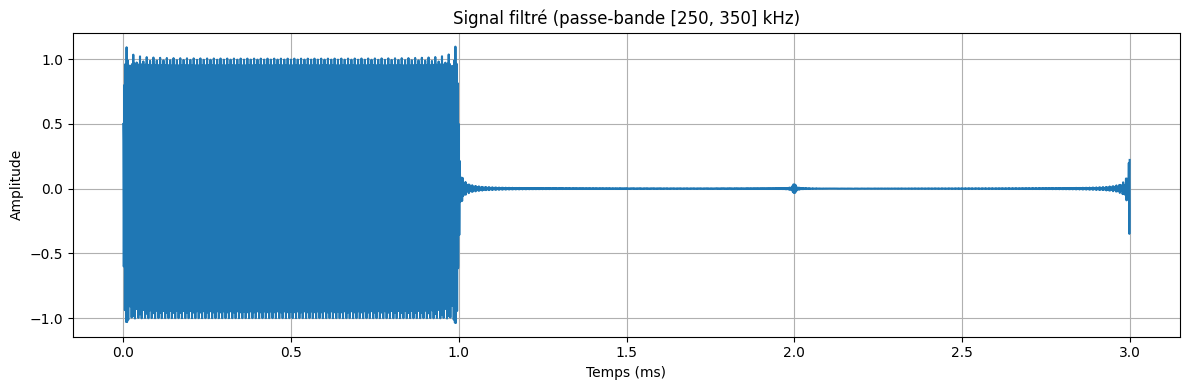

In [5]:
# Q5 - Signal filtré dans le domaine temporel
s1_filtre = np.real(np.fft.ifft(S1_filtre))

plt.figure(figsize=(12, 4))
plt.plot(t * 1e3, s1_filtre)
plt.title('Signal filtré (passe-bande [250, 350] kHz)')
plt.xlabel('Temps (ms)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

*Commentaires*: 

Le signal filtré ne conserve que la composante à 300 kHz. On observe un cosinus à 300 kHz uniquement pendant la première milliseconde (là où cette fréquence est présente dans le signal original). Les deux autres portions (500 kHz et 700 kHz) sont éliminées par le filtre passe-bande.

**6)- 3pts** Re-générer le signal $s1$, mais avec une fréquence d'échantillonnage de $1000 kHz$.

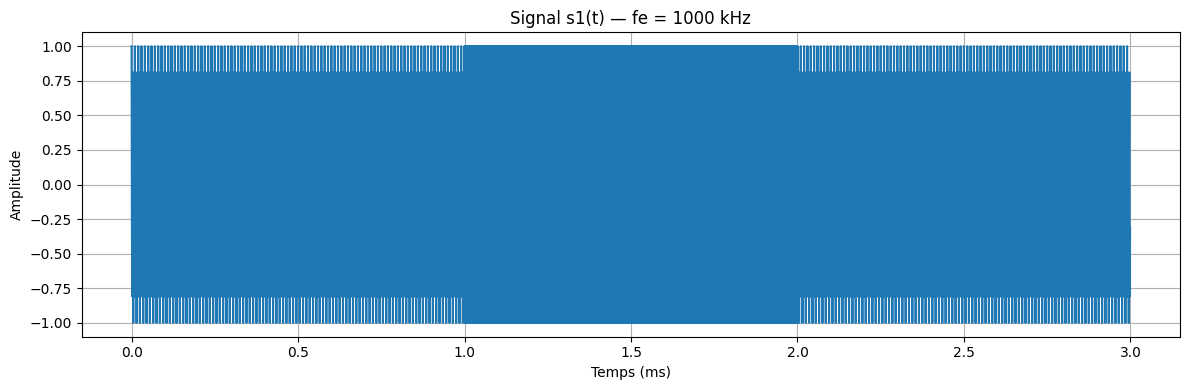

In [6]:
# Q6 - Signal s1 avec fe = 1000 kHz
fe2 = 1000e3
Te2 = 1 / fe2
t2 = np.arange(0, duree, Te2)
N2 = len(t2)

s1_b = np.zeros(N2)
n1b = int(1e-3 / Te2)
n2b = int(2e-3 / Te2)

s1_b[:n1b] = np.cos(2 * np.pi * 300e3 * t2[:n1b])
s1_b[n1b:n2b] = np.cos(2 * np.pi * 500e3 * t2[n1b:n2b])
s1_b[n2b:] = np.cos(2 * np.pi * 700e3 * t2[n2b:])

plt.figure(figsize=(12, 4))
plt.plot(t2 * 1e3, s1_b)
plt.title(f'Signal s1(t) — fe = {fe2/1e3:.0f} kHz')
plt.xlabel('Temps (ms)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

**7)- 3pts** Calculer la transformée de Fourier de ce signal et afficher son module, en faisant clairement apparaître l’axe des fréquences en $Hz$.

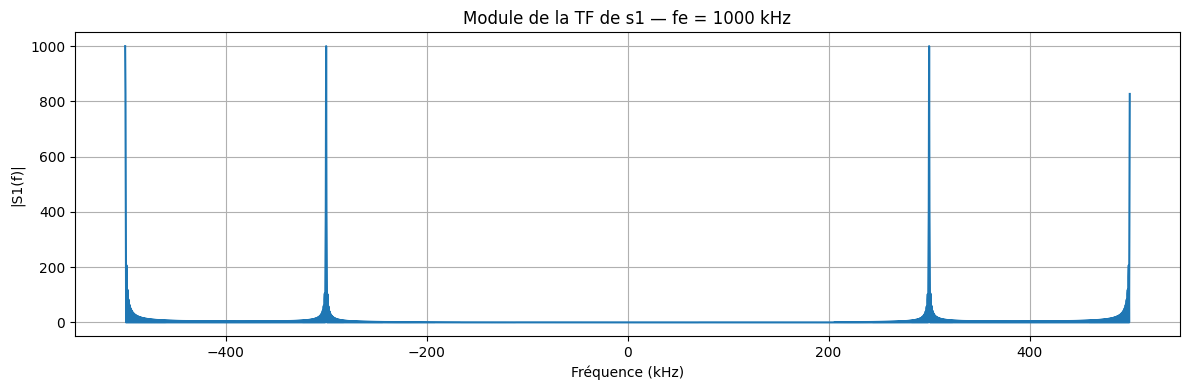

In [7]:
# Q7 - TF du signal avec fe = 1000 kHz
S1_b = np.fft.fft(s1_b)
freqs2 = np.fft.fftfreq(N2, d=Te2)

plt.figure(figsize=(12, 4))
plt.plot(np.fft.fftshift(freqs2) / 1e3, np.abs(np.fft.fftshift(S1_b)))
plt.title(f'Module de la TF de s1 — fe = {fe2/1e3:.0f} kHz')
plt.xlabel('Fréquence (kHz)')
plt.ylabel('|S1(f)|')
plt.grid(True)
plt.tight_layout()
plt.show()

**8)- 3pts** Est-ce que ce signal a été correctement échantillonné ? Justifier votre réponse.

*Commentaires*: 

Avec $f_e = 1000$ kHz, la fréquence de Nyquist est $f_e/2 = 500$ kHz. Or le signal contient une composante à $700$ kHz $> 500$ kHz : le théorème de Shannon **n'est pas respecté**. La composante à 700 kHz subit un **repliement spectral** (aliasing) : elle apparaît à $f_e - 700 = 300$ kHz, se confondant avec la composante à 300 kHz. Le signal n'est donc **pas correctement échantillonné**.

***